# Low-Dimensional Performance Experimant

Test MoLA against traditional CDMs on the low-dimensional fraction-subtraction dataset on various performance metrics.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Allows import of modules from src/ in root
%cd ..

/Users/marialentini/Library/CloudStorage/OneDrive-Pearson/Research/Mixture-of-Latent-Archetypes


## Prepare Datasets

Download the fraction-subtraction dataset. Generate random train/test splits.

In [3]:
from src.utils.datasets import download_frac_subtr_to_pandas
import rpy2.robjects as ro

# Download fraction-subtraction datasets
X_df = download_frac_subtr_to_pandas('fraction.subtraction.data')
Q_df = download_frac_subtr_to_pandas('fraction.subtraction.qmatrix')

from sklearn.model_selection import ShuffleSplit
ss = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)

splits = []
for train_idx, test_idx in ss.split(X_df):
    X_train_df = X_df.iloc[train_idx]
    X_test_df = X_df.iloc[test_idx]
    splits.append((X_train_df, X_test_df))

# Get the citation object
citation = ro.r('citation("CDM")')
citation = ro.r('toBibtex(citation("CDM"))')

## Run Experiment

Train CDMs (DINA, GDINA and HO-DINA) and MoLA on all train/test splits.

In [13]:
import pandas as pd
import numpy as np
from src.experiments.low_dim import fit_mola, run_experiment

In [ ]:
%%capture
final_results = []

# Fit classical CDMs
for model_name in ["DINA", "GDINA", "HO-DINA"]:
    result = run_experiment(model_name, splits, Q_df)
    final_results.append(result)

# Fit MoLA
result = fit_mola(splits, Q_df)
final_results.append(result)

## Compile Results Table

Saves results to results/ folder in `low-dim-results.csv`.

In [19]:
results_df = pd.DataFrame([
    {
        "Model": result['model'],
        "auc_train": np.mean(result['auc_train']),
        "Test AUC": np.mean(result['auc_test']),
        "nll_train": np.mean(result['nll_train']),
        "Test NLL": np.mean(result['nll_test']),
        "brier_train": np.mean(result['brier_train']),
        "Test Brier": np.mean(result['brier_test'])
    } 
    for result in final_results
])

results_df.to_csv('results/low-dim-results.csv')
results_df.round(3)

,Model,auc_train,Test AUC,nll_train,Test NLL,brier_train,Test Brier
0,DINA,0.899,0.893,0.274,0.278,0.128,0.131
1,GDINA,0.925,0.904,0.249,0.268,0.104,0.118
2,HO-DINA,0.912,0.903,0.289,0.296,0.111,0.117
3,MoLA,0.912,0.891,0.330,0.330,0.117,0.127


## Visualize Callibration

/Users/marialentini/Library/CloudStorage/OneDrive-Pearson/Research/Mixture-of-Latent-Archetypes/src/experiments/low_dim.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_masked = X_df.astype(float, copy=True)
/Users/marialentini/Library/CloudStorage/OneDrive-Pearson/Research/Mixture-of-Latent-Archetypes/src/experiments/low_dim.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_masked = X_df.astype(float, copy=True)
/Users/marialentini/Library/CloudStorage/OneDrive-Pearson/Research/Mixture-of-Latent-Archetypes/src/experiments/low_dim.py:12: FutureWarning: The default of observed=False is deprecated an

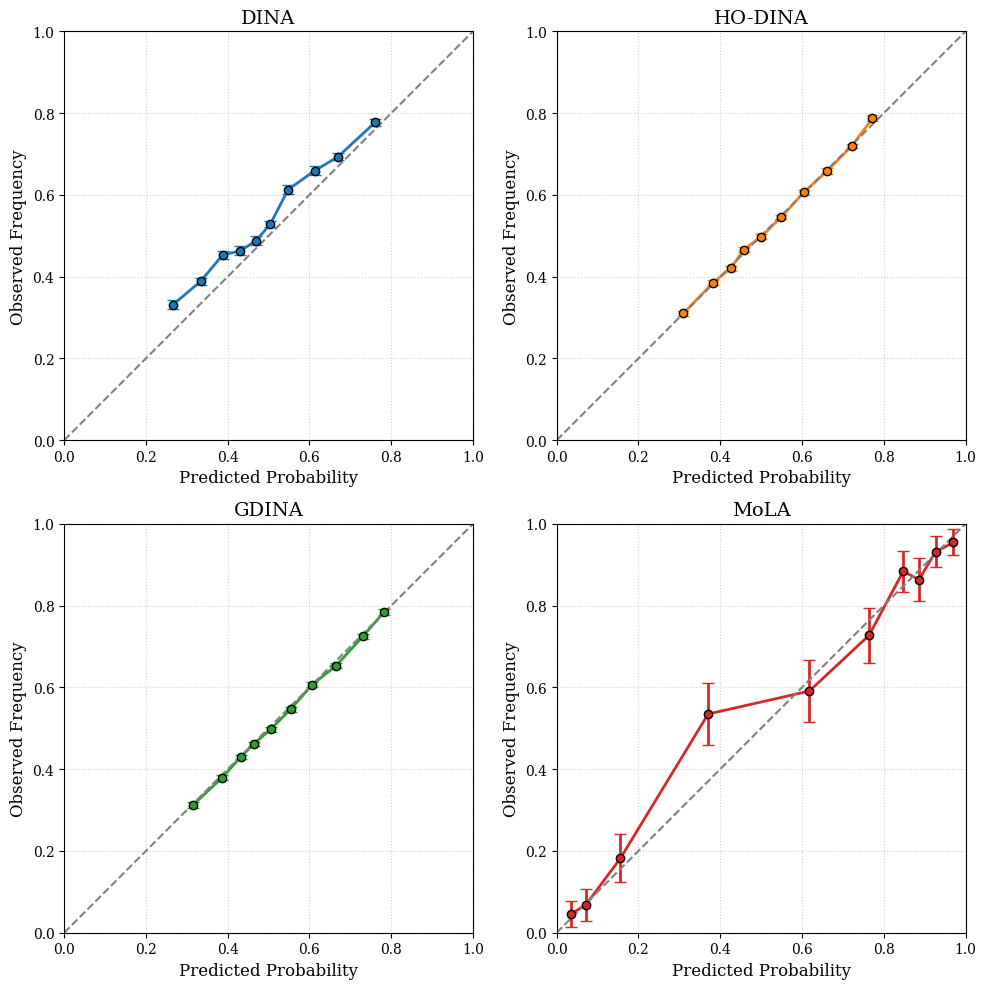

In [22]:
from src.experiments.low_dim import plot_calibrations

model_names = ["DINA", "HO-DINA", "GDINA", "MoLA"]
plot_calibrations(final_results, model_names, n_bins=10)

DINA 0.0059100670255086765 0.0059100670255086765
HO-DINA 0.0012321597543775017 0.0012321597543775017
GDINA 0.0012902821373530235 0.0012902821373530235
MoLA 0.12736838006556842 0.12736838006556842


/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_48698/2990097856.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = data.groupby('bin').agg(
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_48698/2990097856.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = data.groupby('bin').agg(
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_48698/2990097856.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

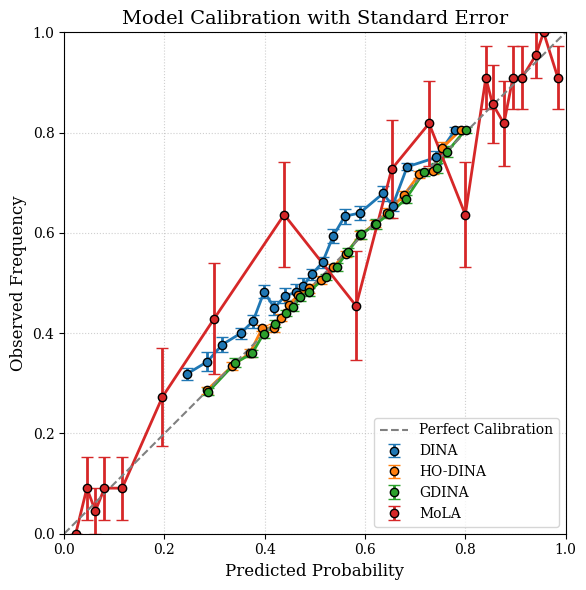

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

def get_brier_score(y_true, y_prob):
    return float(((np.array(y_true) - np.array(y_prob))**2).sum() / len(y_true))

# Use LaTeX fonts for publication-quality text
rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_calibrations_errorbars_outline(final_results, model_names, n_bins=10):
    plt.figure(figsize=(6,6))
    
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    all_preds = []
    all_trues = []
    
    for i, model_name in enumerate(model_names):
        results = [r for r in final_results if r['model'] == model_name][0]
        avg_y_probas = np.array(results['y_probas_test']).mean(axis=0)
        avg_y_true = np.array(results['y_true_test']).mean(axis=0)
        data = pd.DataFrame({'y_proba': avg_y_probas, 'y_true': avg_y_true})

        print(model_name, np.mean((avg_y_probas - avg_y_true)**2),get_brier_score(avg_y_true, avg_y_probas))
        
        data['bin'] = pd.qcut(data['y_proba'], q=n_bins, duplicates='drop')
        calibration = data.groupby('bin').agg(
            mean_pred=('y_proba', 'mean'),
            mean_true=('y_true', 'mean'),
            std_true=('y_true', 'std'),
            count=('y_true', 'size')
        ).reset_index()
        
        calibration['sem_true'] = calibration['std_true'] / np.sqrt(calibration['count'])
        all_preds.append(calibration['mean_pred'].values)
        all_trues.append(calibration['mean_true'].values)
        
        # Plot with error bars and outlined markers
        plt.errorbar(
            calibration['mean_pred'],
            calibration['mean_true'],
            yerr=calibration['sem_true'],
            fmt='o',
            markersize=6,
            linewidth=2,
            capsize=4,
            color=colors[i],
            markerfacecolor=colors[i],
            markeredgecolor='black',  # outline
            label=model_name
        )

        plt.plot(
            calibration['mean_pred'],
            calibration['mean_true'],
            linewidth=2,
        )
    
    # Perfect calibration line: span the visible range
    all_preds_flat = np.concatenate(all_preds)
    all_trues_flat = np.concatenate(all_trues)
    vmin = min(all_preds_flat.min(), all_trues_flat.min())
    vmax = max(all_preds_flat.max(), all_trues_flat.max())
    margin = 0.05
    # plt.plot([vmin - margin, vmax + margin], [vmin - margin, vmax + margin], linestyle='--', color='gray', linewidth=1.5, label='Perfect Calibration')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5, label='Perfect Calibration')
    # Tight axis limits with small margin
    plt.xlim(max(0, vmin - margin), min(1, vmax + margin))
    plt.ylim(max(0, vmin - margin), min(1, vmax + margin))
    
    # Make sure 45-degree line is actually 45° visually
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.xlabel('Predicted Probability')
    plt.ylabel('Observed Frequency')
    plt.title('Model Calibration with Standard Error')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    plt.tight_layout()
    
# Example usage
plot_calibrations_errorbars_outline(final_results, ["DINA", "HO-DINA", "GDINA", "MoLA"], n_bins=20)

# plt.savefig("figures/frac-subtr-calibration.pdf", bbox_inches="tight")
# plt.savefig("figures/frac-subtr-calibration.svg", bbox_inches="tight")
# plt.savefig("figures/frac-subtr-calibration.png", dpi=300, bbox_inches="tight")

plt.show()

In [24]:


# Example usage
plot_calibrations_errorbars_outline(
    final_results,
    ["DINA", "HO-DINA", "GDINA", "MoLA"],
    n_bins=20
)

plt.savefig("figures/frac-subtr-calibration.pdf", bbox_inches="tight")
plt.savefig("figures/frac-subtr-calibration.svg", bbox_inches="tight")
plt.savefig("figures/frac-subtr-calibration.png", dpi=300, bbox_inches="tight")

plt.show()

NameError: name 'get_brier_score' is not defined

<Figure size 600x600 with 0 Axes>

DINA 0.0059100670255086765 0.0059100670255086765
HO-DINA 0.0012321597543775017 0.0012321597543775017
GDINA 0.0012902821373530235 0.0012902821373530235
MoLA 0.001624536075153757 0.001624536075153757


/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_89584/989959433.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = data.groupby('bin').agg(
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_89584/989959433.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = data.groupby('bin').agg(
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_89584/989959433.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

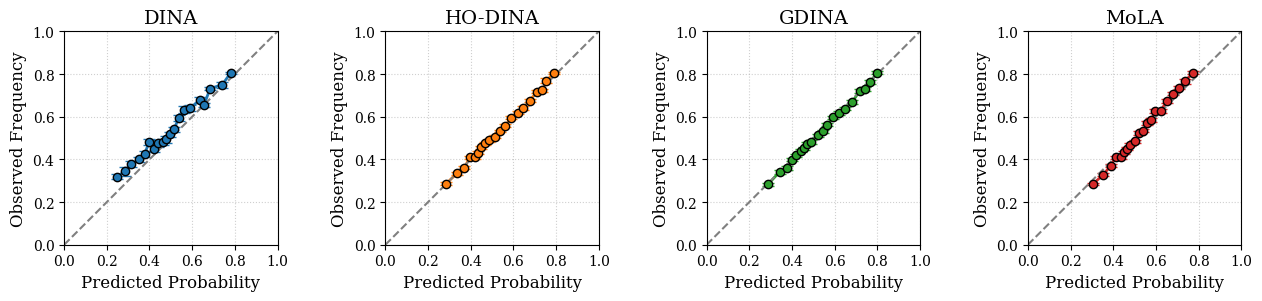

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

# Use LaTeX-style publication formatting
rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

def plot_calibrations_errorbars_outline(final_results, model_names, n_bins=10):
    
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    # 1x4 layout (single row, four columns)
    fig, axes = plt.subplots(1, 4, figsize=(13, 3))
    axes = axes.flatten()

    for i, model_name in enumerate(model_names):

        ax = axes[i]

        results = [r for r in final_results if r['model'] == model_name][0]

        avg_y_probas = np.array(results['y_probas_test']).mean(axis=0)
        avg_y_true = np.array(results['y_true_test']).mean(axis=0)

        data = pd.DataFrame({
            'y_proba': avg_y_probas,
            'y_true': avg_y_true
        })

        print(
            model_name,
            np.mean((avg_y_probas - avg_y_true) ** 2),
            get_brier_score(avg_y_true, avg_y_probas)
        )

        data['bin'] = pd.qcut(
            data['y_proba'],
            q=n_bins,
            duplicates='drop'
        )

        calibration = data.groupby('bin').agg(
            mean_pred=('y_proba', 'mean'),
            mean_true=('y_true', 'mean'),
            std_true=('y_true', 'std'),
            count=('y_true', 'size')
        ).reset_index()

        calibration['sem_true'] = (
            calibration['std_true'] /
            np.sqrt(calibration['count'])
        )

        # Plot calibration points with error bars
        ax.errorbar(
            calibration['mean_pred'],
            calibration['mean_true'],
            yerr=calibration['sem_true'],
            fmt='o',
            markersize=6,
            linewidth=2,
            capsize=4,
            color=colors[i],
            markerfacecolor=colors[i],
            markeredgecolor='black'
        )

        # Connect points
        ax.plot(
            calibration['mean_pred'],
            calibration['mean_true'],
            linewidth=2,
            color=colors[i]
        )

        # Perfect calibration reference line
        ax.plot(
            [0, 1],
            [0, 1],
            linestyle='--',
            color='gray',
            linewidth=1.5
        )

        # Formatting
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_aspect('equal', adjustable='box')

        ax.set_title(model_name)

        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Observed Frequency')

        ax.grid(True, linestyle=':', alpha=0.6)

    # Remove unused axes if fewer than 4 models
    for j in range(len(model_names), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

# Example usage
plot_calibrations_errorbars_outline(
    final_results,
    ["DINA", "HO-DINA", "GDINA", "MoLA"],
    n_bins=20
)

plt.savefig("figures/frac-subtr-calibration-2.pdf", bbox_inches="tight")
plt.savefig("figures/frac-subtr-calibration-2.svg", bbox_inches="tight")
plt.savefig("figures/frac-subtr-calibration-2.png", dpi=300, bbox_inches="tight")

plt.show()

/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_89584/1667175034.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = data.groupby('bin').agg(
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_89584/1667175034.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = data.groupby('bin').agg(
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_89584/1667175034.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

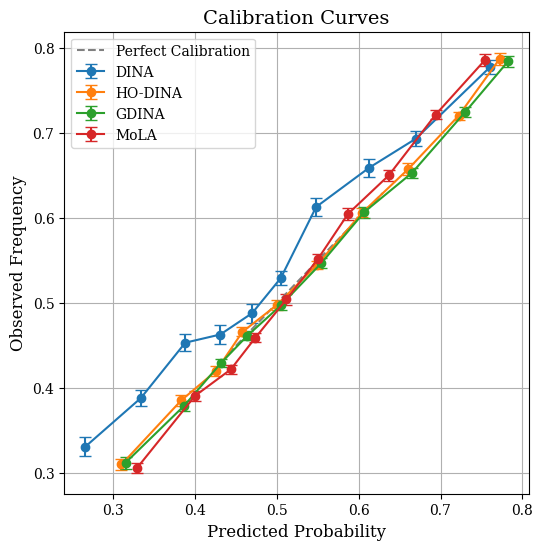

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_calibrations(final_results, model_names, n_bins=10):
    plt.figure(figsize=(6,6))
    
    for model_name in model_names:
        results = [r for r in final_results if r['model'] == model_name][0]
        avg_y_probas = np.array(results['y_probas_test']).mean(axis=0)
        avg_y_true = np.array(results['y_true_test']).mean(axis=0)
        data = pd.DataFrame({'y_proba': avg_y_probas, 'y_true': avg_y_true})
        
        # Use quantile binning to avoid empty bins
        data['bin'] = pd.qcut(data['y_proba'], q=n_bins, duplicates='drop')
        
        # Group by bin
        calibration = data.groupby('bin').agg(
            mean_pred=('y_proba', 'mean'),
            mean_true=('y_true', 'mean'),
            std_true=('y_true', 'std'),
            count=('y_true', 'size')
        ).reset_index()
        
        calibration['sem_true'] = calibration['std_true'] / np.sqrt(calibration['count'])
        
        # Plot error bars for this model
        plt.errorbar(
            calibration['mean_pred'],
            calibration['mean_true'],
            yerr=calibration['sem_true'],
            fmt='o-',
            capsize=4,
            label=model_name
        )
    
    # Perfect calibration line
    all_preds = np.concatenate([
        np.array([np.mean(r['y_probas_test'], axis=1) for r in final_results if r['model'] in model_names])
    ]).flatten()
    x_min, x_max = all_preds.min(), all_preds.max()
    plt.plot([x_min, x_max], [x_min, x_max], linestyle='--', color='gray', label='Perfect Calibration')
    
    plt.xlabel('Predicted Probability')
    plt.ylabel('Observed Frequency')
    plt.title('Calibration Curves')
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage
plot_calibrations(final_results, ["DINA", "HO-DINA", "GDINA", "MoLA"])

              bin  mean_pred  mean_true  std_true  count
0   (0.44, 0.453]   0.442865   0.501142  0.004843      2
1  (0.453, 0.467]   0.460751   0.511669  0.021431      9
2   (0.467, 0.48]   0.474017   0.511208  0.021085     11
3   (0.48, 0.493]   0.486378   0.525475  0.022282     19
4  (0.493, 0.506]   0.499453   0.537726  0.020094     21
5  (0.506, 0.519]   0.513559   0.553183  0.020497     17
6  (0.519, 0.532]   0.523961   0.567428  0.017703     15
7  (0.532, 0.545]   0.537568   0.577626  0.017977      4
8  (0.545, 0.558]   0.545482   0.611872       NaN      1
9  (0.558, 0.571]   0.571066   0.621005       NaN      1


/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_694/3925780647.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = data.groupby('bin').agg(


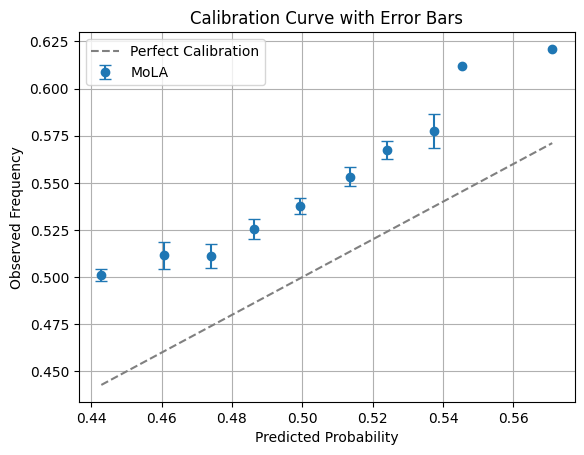

In [100]:
def plot_calibration(final_results, model_name):
    
    results = [result for result in final_results if result['model'] == model_name][0]
    avg_y_probas = np.array(results['y_probas_test']).mean(axis=1)
    avg_y_true = np.array(results['y_true_test']).mean(axis=1)

    # Assuming avg_y_probas and avg_y_true are (N,) arrays
    data = pd.DataFrame({'y_proba': avg_y_probas, 'y_true': avg_y_true})

    # Number of bins
    n_bins = 10
    data['bin'] = pd.cut(data['y_proba'], bins=n_bins)
    # data['bin'] = pd.qcut(data['y_proba'], q=10, duplicates='drop')  # drops empty/duplicate bins

    # Group by bins
    calibration = data.groupby('bin').agg(
        mean_pred=('y_proba', 'mean'),
        mean_true=('y_true', 'mean'),
        std_true=('y_true', 'std'),
        count=('y_true', 'size')
    ).reset_index()

    print(calibration)

    # Standard error of the mean
    calibration['sem_true'] = calibration['std_true'] / np.sqrt(calibration['count'])

    # Plot with error bars
    plt.errorbar(
        calibration['mean_pred'],
        calibration['mean_true'],
        yerr=calibration['sem_true'],
        fmt='o',
        capsize=4,
        label='MoLA'
    )
    # Perfect calibration line: use min/max of predicted probabilities
    x_min, x_max = calibration['mean_pred'].min(), calibration['mean_pred'].max()
    plt.plot([x_min, x_max], [x_min, x_max], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Observed Frequency')
    plt.title('Calibration Curve with Error Bars')
    plt.grid(True)
    plt.legend()
    plt.show()

plot_calibration(final_results, "DINA")

## Final Results

In [14]:
results_df = pd.DataFrame([
    {
        "Model": result['model'],
        "auc_train": np.mean(result['auc_train']),
        "Test AUC": np.mean(result['auc_test']),
        "nll_train": np.mean(result['nll_train']),
        "Test NLL": np.mean(result['nll_test']),
        "brier_train": np.mean(result['brier_train']),
        "Test Brier": np.mean(result['brier_test'])
    } 
    for result in final_results
])

results_df.to_csv('data/frac-subtr-experiment.csv')
results_df.round(3)

,Model,auc_train,Test AUC,nll_train,Test NLL,brier_train,Test Brier
0,DINA,0.899,0.893,0.274,0.278,0.128,0.131
1,HO-DINA,0.912,0.903,0.289,0.296,0.111,0.117
2,GDINA,0.925,0.904,0.249,0.268,0.104,0.118
3,MoLA,0.900,0.893,0.358,0.363,0.127,0.130


In [15]:
# Load CSV
results_df = pd.read_csv('data/frac-subtr-experiment.csv', index_col=0)
results_df = results_df[['Model', 'Test AUC', 'Test NLL', 'Test Brier']]

# Function to bold best values per column
def bold_max(s):
    is_max = s == s.max()
    return ['\\textbf{' + str(v) + '}' if m else str(v) for v, m in zip(s, is_max)]

# Round numeric columns to 3 decimals and convert to strings
df_rounded = results_df.copy()
for col in df_rounded.columns:
    if pd.api.types.is_numeric_dtype(df_rounded[col]):
        df_rounded[col] = df_rounded[col].map(lambda x: f"{x:.3f}")

# # Apply bolding to numeric columns
# df_bold = results_df.copy()
# for col in df_bold.columns:
#     if pd.api.types.is_numeric_dtype(df_bold[col]):
#         df_bold[col] = bold_max(df_bold[col])

# Convert to LaTeX
latex_table = df_rounded.set_index('Model').to_latex(escape=False)
print(latex_table)

\begin{tabular}{llll}
\toprule
 & Test AUC & Test NLL & Test Brier \\
Model &  &  &  \\
\midrule
DINA & 0.893 & 0.278 & 0.131 \\
HO-DINA & 0.903 & 0.296 & 0.117 \\
GDINA & 0.904 & 0.268 & 0.118 \\
MoLA & 0.893 & 0.363 & 0.130 \\
\bottomrule
\end{tabular}



## Varying Number of Components

We should not have to worry about overfitting. 

In [159]:
[2**k for k in range(1, 18, 2)]

[2, 8, 32, 128, 512, 2048, 8192, 32768, 131072]

In [171]:
from aplus.cognitive_model import MoLA
from tqdm import tqdm
final_results = []

m_values = [2**k for k in range(2, 18, 2)]
for m in tqdm(m_values):
    auc_trains, auc_tests = [], []
    nll_trains, nll_tests = [], []
    brier_trains, brier_tests = [], []
    y_true_tests, y_probas_tests = [], []
    for X_train_df, X_test_df in splits[:10]:

        X_train = X_train_df.to_numpy()
        X_test = X_test_df.to_numpy()
        Q_matrix = Q_df.to_numpy()

        X_train[X_train == -1] = 0
        X_test[X_test == -1] = 0

        # Configure model parameters
        model_params = {
            'Q_matrix': Q_matrix,
            'n_components': m,
            'mu_smooth': [2, 2],
            'theta_smooth': [2, 2],
            'pi_smooth': 2,
            'tol': 1e-6,
            'n_iter': 500,
        }

        # Instantiate the model
        model = MoLA(**model_params)

        # Fit the model to the data
        model.fit(X_train)

        # Prediction
        y_proba_train, y_true_train = get_y_proba_and_true(model, X_train)
        y_proba_test, y_true_test = get_y_proba_and_true(model, X_test)

        y_true_tests.append(y_true_test)
        y_probas_tests.append(y_proba_test)

        # AUC scores
        auc_trains.append(roc_auc_score(y_true_train, y_proba_train))
        auc_tests.append(roc_auc_score(y_true_test, y_proba_test))

        # Brier scores
        brier_tests.append(get_brier_score(y_proba_test, y_true_test))
        brier_trains.append(get_brier_score(y_proba_train, y_true_train))

        # NLL scores
        nll_trains.append(model.get_pred_nll(X_train))
        nll_tests.append(model.get_pred_nll(X_test))

    result = {
        "nll_train": nll_trains,
        "nll_test": nll_tests,
        "auc_train": auc_trains,
        "auc_test": auc_tests,
        "brier_train": brier_trains,
        "brier_test": brier_tests,
        "y_probas_test": y_probas_tests,
        "y_true_test": y_true_tests
    }

    final_results.append(result) 

100%|██████████| 8/8 [09:30<00:00, 71.32s/it] 


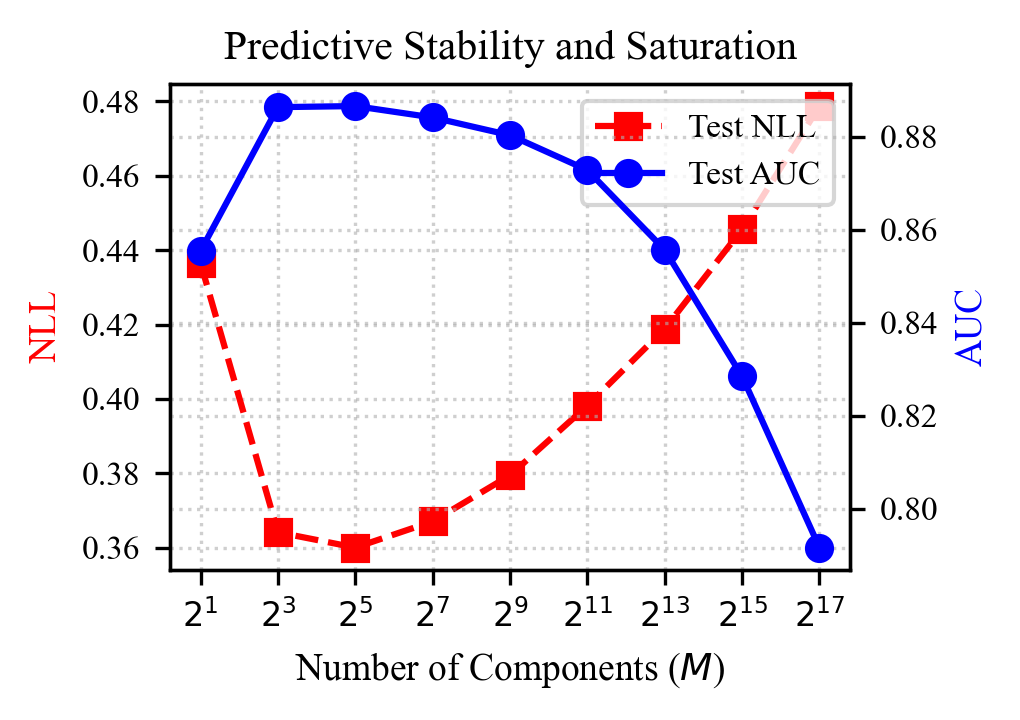

In [164]:
col_width = 3.5 
fig_height = 2.5

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,          # Base font size
    "axes.titlesize": 10,     # Title size
    "axes.labelsize": 9,      # Axis labels
    "xtick.labelsize": 8,     # Tick labels
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 300
})

fig, ax3 = plt.subplots(figsize=(col_width, fig_height))

# --- PANEL 3: STABILITY (NLL/AUC) ---
# Dual-axis plot for the final panel
ax3_twin = ax3.twinx()
m_vals_perf = [2**k for k in range(1, 18, 2)]
# Replace with your actual mean performance data
train_nll = [np.mean(r['nll_train']) for r in final_results]
test_nll = [np.mean(r['nll_test']) for r in final_results]
train_auc = [np.mean(r['auc_train']) for r in final_results]
test_auc = [np.mean(r['auc_test']) for r in final_results]

lns1 = ax3.plot(m_vals_perf, test_nll, 's--', color='red', label='Test NLL')
lns2 = ax3_twin.plot(m_vals_perf, test_auc, 'o-', color='blue', label='Test AUC')

ax3.set_xscale('log', base=2)
ax3.set_xticks(m_vals_perf)
ax3.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax3.set_title("Predictive Stability and Saturation")
ax3.set_xlabel("Number of Components ($M$)")
ax3.set_ylabel("NLL", color='red')
ax3_twin.set_ylabel("AUC", color='blue')

# Combined Legend for dual axis
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax3.legend(lns, labs, loc='upper right', fontsize=8)
ax3.grid(True)

pow_labels = [f"$2^{{{m}}}$" for m in range(1, 18, 2)]
ax3.set_xticklabels(pow_labels)

plt.tight_layout()
plt.savefig("figures/overfitting_test.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [170]:
print('Components:', pow_labels)
print('Test NLL:', [round(float(i), 3) for i in test_nll])
print('Test AUC:', [round(float(i), 3) for i in test_auc])

Components: ['$2^{1}$', '$2^{3}$', '$2^{5}$', '$2^{7}$', '$2^{9}$', '$2^{11}$', '$2^{13}$', '$2^{15}$', '$2^{17}$']
Test NLL: [0.437, 0.364, 0.36, 0.367, 0.379, 0.398, 0.419, 0.446, 0.479]
Test AUC: [0.855, 0.886, 0.887, 0.884, 0.88, 0.873, 0.856, 0.829, 0.792]


In [165]:
diff_nll = (abs(min(test_nll) - test_nll[-1]))/ min(test_nll)
diff_auc = (abs(max(test_auc) - test_auc[-1]))/ max(test_auc)
print('Min NLL:', min(test_nll), ', Large Comp NLL:', test_nll[-1], ", Pct diff:", diff_nll)
print('Max AUC:', max(test_auc), ', Large Comp AUC:', test_auc[-1], ", Pct diff:", diff_auc)

Min NLL: 0.3600223981564049 , Large Comp NLL: 0.478728085766188 , Pct diff: 0.32971750707080644
Max AUC: 0.8865888110083727 , Large Comp AUC: 0.7917033026945727 , Pct diff: 0.1070231285751067


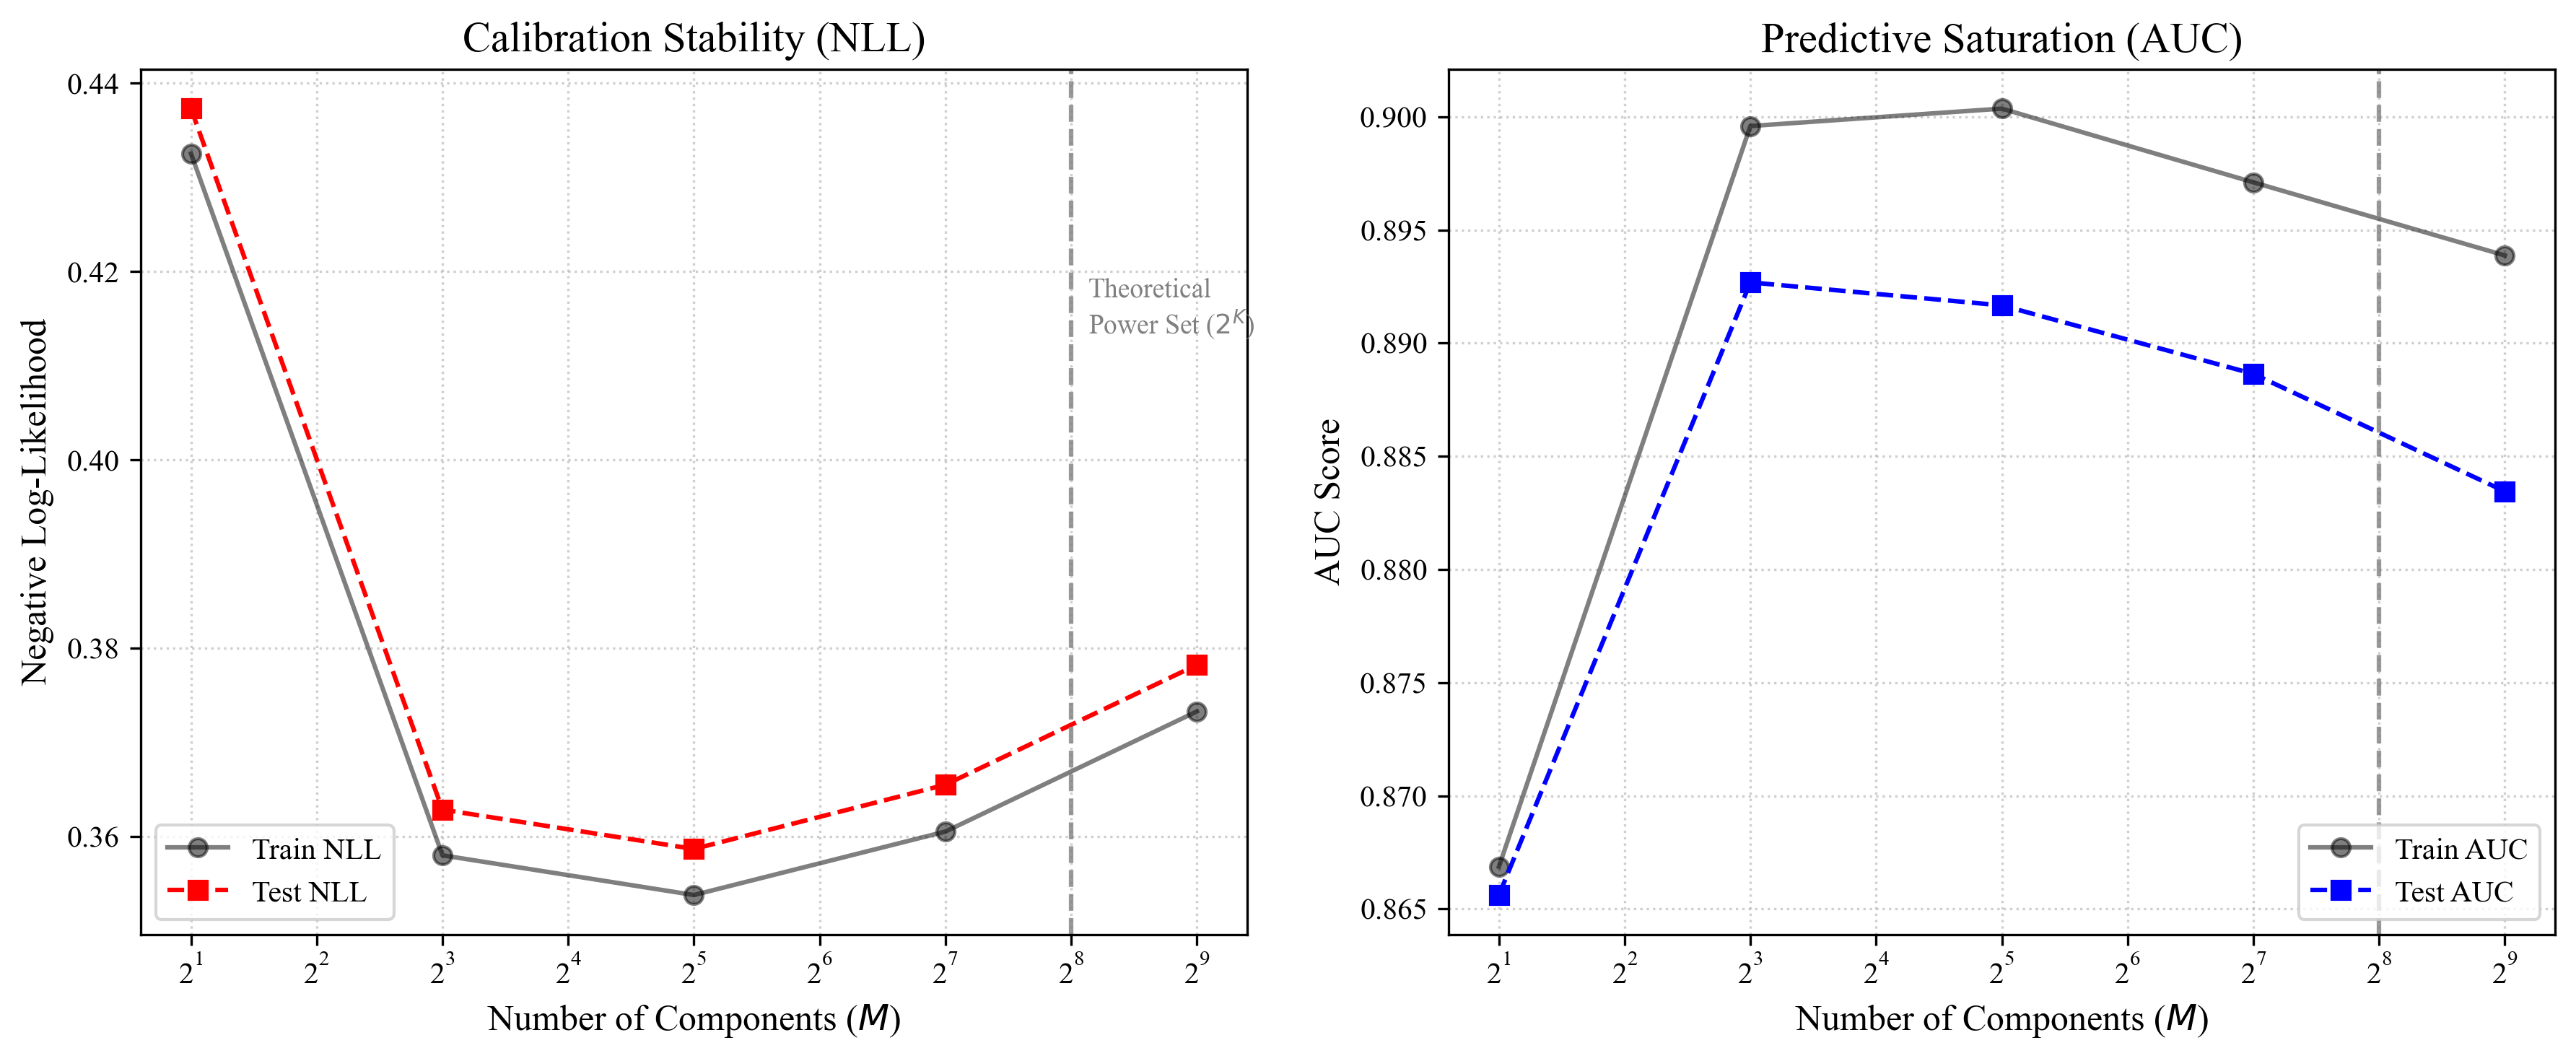

In [127]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# 1. High-End Publication Config
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "figure.dpi": 300,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.6
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Power Set Constant
POWER_SET = 256 # 2^8

# --- Panel 1: Calibration (NLL) ---
m_vals = np.array([2**k for k in range(1, 10, 2)])
# (Assuming your final_results data here)
train_nll = [np.mean(r['nll_train']) for r in final_results]
test_nll = [np.mean(r['nll_test']) for r in final_results]

ax1.plot(m_vals, train_nll, 'o-', color='black', alpha=0.5, label='Train NLL')
ax1.plot(m_vals, test_nll, 's--', color='red', label='Test NLL')

# Vertical Reference Line
ax1.axvline(POWER_SET, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.text(POWER_SET * 1.1, ax1.get_ylim()[1]*0.95, "Theoretical\nPower Set ($2^K$)", 
         color='gray', fontsize=9, verticalalignment='top')

ax1.set_xscale('log', base=2)
ax1.set_title("Calibration Stability (NLL)")
ax1.set_xlabel("Number of Components ($M$)")
ax1.set_ylabel("Negative Log-Likelihood")
ax1.legend()

# --- Panel 2: Predictive Power (AUC) ---
train_auc = [np.mean(r['auc_train']) for r in final_results]
test_auc = [np.mean(r['auc_test']) for r in final_results]

ax2.plot(m_vals, train_auc, 'o-', color='black', alpha=0.5, label='Train AUC')
ax2.plot(m_vals, test_auc, 's--', color='blue', label='Test AUC')

# Vertical Reference Line
ax2.axvline(POWER_SET, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

ax2.set_xscale('log', base=2)
ax2.set_title("Predictive Saturation (AUC)")
ax2.set_xlabel("Number of Components ($M$)")
ax2.set_ylabel("AUC Score")
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()


In [133]:
print([float(i) for i in test_auc])
print([float(i) for i in test_nll])

[0.8656178457213514, 0.8926837921522227, 0.8916669352558517, 0.8886420145421249, 0.8834514474500215]
[0.4372715103392736, 0.36286104053359153, 0.3586875819363884, 0.36550615372770084, 0.37822787369900474]


In [117]:
from aplus.cognitive_model import MoLA

auc_trains, auc_tests = [], []
nll_trains, nll_tests = [], []
brier_trains, brier_tests = [], []
y_true_tests, y_probas_tests = [], []

result = {}
for X_train_df, X_test_df in splits:
    for K in range(2, 8+1):
        X_train = X_train_df.to_numpy()
        X_test = X_test_df.to_numpy()
        Q_matrix = Q_df.to_numpy()
        X_train[X_train == -1] = 0
        X_test[X_test == -1] = 0

        # Configure model parameters
        model_params = {
            'Q_matrix': Q_matrix,
            'n_components': 2**K,
            'mu_smooth': [2, 2],
            'theta_smooth': [2, 2],
            'pi_smooth': 2,
            'tol': 1e-6,
            'n_iter': 500,
        }

        # Instantiate the model
        model = MoLA(**model_params)

        # Fit the model to the data
        model.fit(X_train)

        # Prediction
        y_proba_train, y_true_train = get_y_proba_and_true(model, X_train)
        y_proba_test, y_true_test = get_y_proba_and_true(model, X_test)

        y_true_tests.append(y_true_test)
        y_probas_tests.append(y_proba_test)

        # AUC scores
        auc_trains.append(roc_auc_score(y_true_train, y_proba_train))
        auc_tests.append(roc_auc_score(y_true_test, y_proba_test))

        # Brier scores
        brier_tests.append(get_brier_score(y_proba_test, y_true_test))
        brier_trains.append(get_brier_score(y_proba_train, y_true_train))

        # NLL scores
        nll_trains.append(model.get_pred_nll(X_train))
        nll_tests.append(model.get_pred_nll(X_test))

        result.setdefault(K, []).append({
            # "model": "MoLA",
            "nll_train": nll_trains[-1],
            "nll_test": nll_tests[-1],
            "auc_train": auc_trains[-1],
            "auc_test": auc_tests[-1],
            "brier_train": brier_trains[-1],
            "brier_test": brier_tests[-1],
            # "y_probas_test": y_probas_tests,
            # "y_true_test": y_true_tests
        })

In [109]:
[np.mean(result[k][0]['auc_train']) for k in [2, 4, 6, 8]]

[r[f'{metric}_train'] for r in runs]
[r[f'{metric}_train'] for r in runs]

[np.float64(0.3819572706325941),
 np.float64(0.37633960629678836),
 np.float64(0.37658405347685986),
 np.float64(0.37805807401777414),
 np.float64(0.38457483843058504),
 np.float64(0.380535819522618),
 np.float64(0.3810413628190131),
 np.float64(0.37913779383376156),
 np.float64(0.3807720739442719),
 np.float64(0.37492049847105824)]

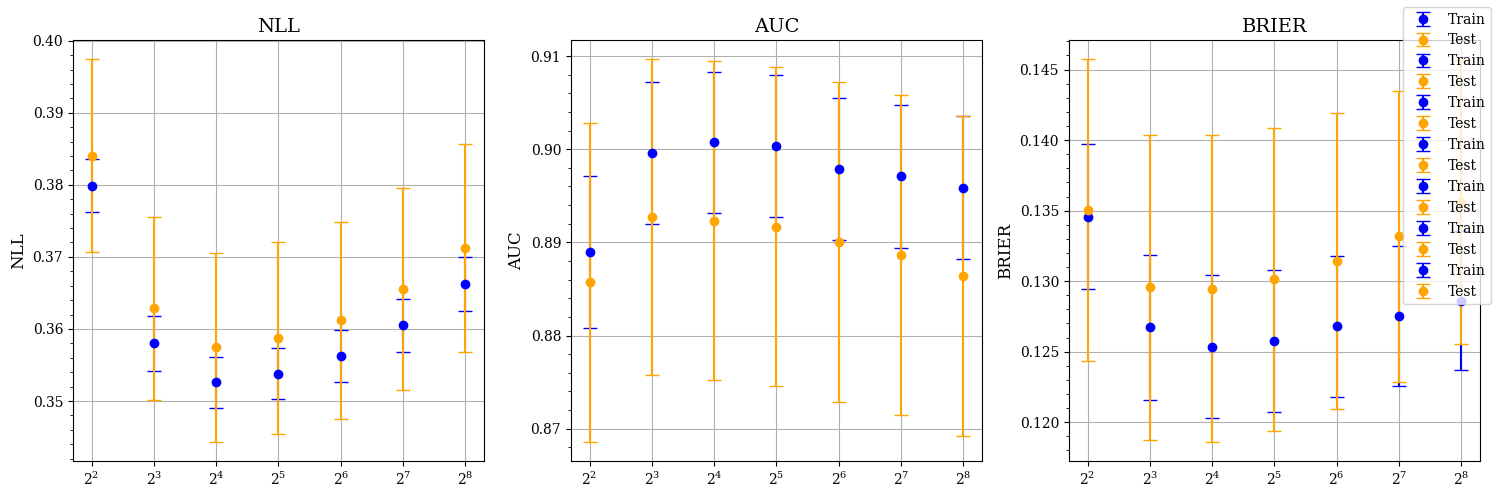

In [121]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Example result structure
# result = {
#     'model1': [
#         {"nll_train": [0.3, 0.31], "nll_test": [0.4, 0.41], "auc_train": [0.9, 0.91], "auc_test": [0.88, 0.87], ...},
#         ...
#     ],
#     ...
# }

metrics = ['nll', 'auc', 'brier']
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for i, metric in enumerate(metrics):
    ax = axes[i]
    for K, runs in result.items():
        # Flatten the list of lists for train/test
        train_values = np.array([r[f'{metric}_train'] for r in runs])
        test_values = np.array([r[f'{metric}_test'] for r in runs])

        mean_train = train_values.mean()
        std_train = train_values.std()
        mean_test = test_values.mean()
        std_test = test_values.std()

        # Plot with error bars
        ax.errorbar(2**K, mean_train, yerr=std_train, fmt='o', label='Train', color='blue', capsize=5)
        ax.errorbar(2**K, mean_test, yerr=std_test, fmt='o', label='Test', color='orange', capsize=5)

    ax.set_title(metric.upper())
    ax.set_ylabel(metric.upper())
    ax.set_xscale('log', base=2)
    ax.grid(True)
    ax.minorticks_on()
    # ax.set_xticks(range(len(result)*2))
    # ax.set_xticklabels([f'{k}_train' for k in result.keys()] + [f'{k}_test' for k in result.keys()], rotation=45)

# Only one legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

In [87]:
std_train

np.float64(0.005809524560923088)

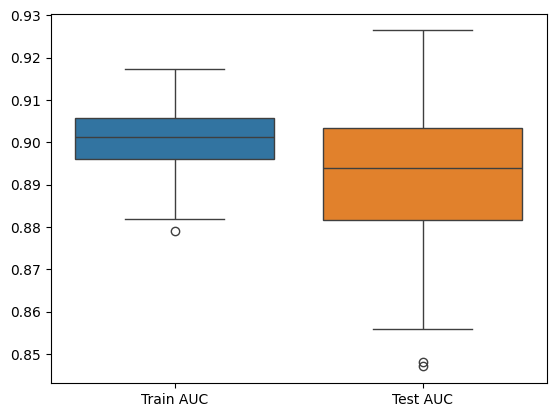

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(pd.DataFrame({
    "Train AUC": mola_auc_trains,
    "Test AUC": mola_auc_tests
}))

plt.show()

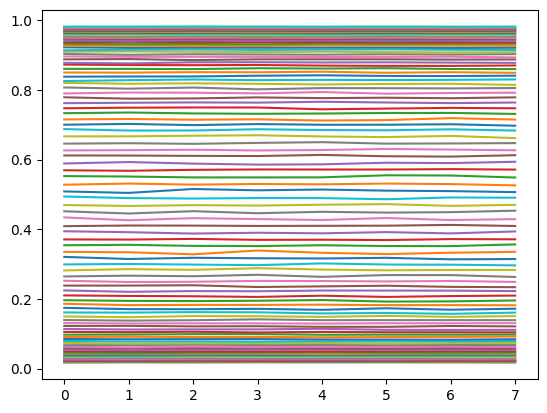

In [190]:
n_components = 100
n_skills = 8

mu = np.array([
    1 / (1 + np.exp(-np.random.normal(x, 1 / n_components, size=n_skills))) 
    for x in np.linspace(-4, 4, n_components)
])

plt.plot(mu.T)
plt.show()

(1500, 8)


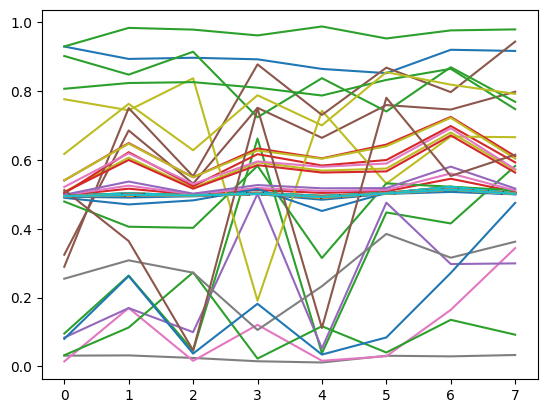

In [16]:
import matplotlib.pyplot as plt

eps = np.finfo(float).eps  # smallest positive float
# mu = np.random.uniform(low=eps, high=1 - eps, size=(n_components, n_skills))
plt.plot(model.mu.T)
print(model.mu.shape)
plt.show()

In [21]:
results_table = [
    {"Model": "DINA", "Train AUC": dina_auc_train, "Test AUC": dina_auc_test,},
    {"Model": "HO-DINA", "Train AUC": hodina_auc_train, "Test AUC": hodina_auc_test},
    {"Model": "GDINA", "Train AUC": gdina_auc_train, "Test AUC": gdina_auc_test},
    {"Model": "MoLA", "Train AUC": mola_auc_train, "Test AUC": mola_auc_test}
]

import pandas as pd
pd.DataFrame(results_table)

,Model,Train AUC,Test AUC
0,DINA,0.904376,0.905100
1,HO-DINA,0.915007,0.916466
2,GDINA,0.928380,0.921272
3,MoLA,0.887595,0.882932


## Prototype GDINA

In [10]:
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri

ro.r("""
     
library(CDM)     
est_model <- CDM::gdina(
    dat = X_train,
    q.matrix = Q_matrix
)
""")

-----------------------------------------------------------------
CDM 8.3-14 (2025-07-13 14:03:01) 
GDINA Model 
 Link function: identity 
  ** 2026-02-01 10:52:03.282037 
-----------------------------------------------------------------
...........................................................
Iteration 1     2026-02-01 10:52:03.304047 
Deviance = 11194.04
Maximum parameter change: 0.292549 
...........................................................
Iteration 2     2026-02-01 10:52:03.312804 
Deviance = 9261.206 | Deviance change = 1932.834
Maximum parameter change: 0.246084 
...........................................................
Iteration 3     2026-02-01 10:52:03.323548 
Deviance = 8874.602 | Deviance change = 386.6044
Maximum parameter change: 0.292192 
...........................................................
Iteration 4     2026-02-01 10:52:03.353825 
Deviance = 8707.35 | Deviance change = 167.2521
Maximum parameter change: 0.128591 
....................................

### Predict Item Probas

In [15]:
ro.r("""
print(names(est_model))

# 1. Get IRFs [n_items x 2^n_skills]
irfs_success <- est_model$pjk[,2 , ]

# 2. get 2^n_skills prior probability for each profile
prior <- est_model$attribute.patt$class.prob

# Adding a tiny constant (1e-10) prevents log(0) errors
log_P <- log(irfs_success + 1e-10)
log_Q <- log(1 - irfs_success + 1e-10)
     
# Ensure X_train is a numeric matrix (N x J)
X_test_mat <- as.matrix(X_train)

# # 2. Compute the Log-Likelihood matrix (N x L)
# # [N x J] %*% [J x L] sums (X * logP)
# # [(N x J)] %*% [J x L] sums ((1-X) * logQ)
# log_lik_matrix <- (X_test_mat %*% log_P) + ((1 - X_test_mat) %*% log_Q)
     
# 1. Create a version of the data where NaNs are 0
X_calc <- X_test_mat
X_calc[is.na(X_calc)] <- 0

# 2. Create an indicator matrix (1 if observed, 0 if masked/NaN)
observed <- matrix(1, nrow=nrow(X_test_mat), ncol=ncol(X_test_mat))
observed[is.na(X_test_mat)] <- 0

# 3. Calculate log-likelihood
# We only sum log_P when X=1 AND observed=1
# We only sum log_Q when X=0 AND observed=1
log_lik_matrix <- (X_calc %*% log_P) + ((observed - X_calc) %*% log_Q)
     
print('hi')
print(dim(log_lik_matrix))
     
# 3. Incorporate the Prior (L-dimensional vector)
# log(Posterior) proportional to log(Likelihood) + log(Prior)
log_prior <- log(prior + 1e-10)
log_posterior_unnorm <- sweep(log_lik_matrix, 2, log_prior, FUN = "+")

# 4. Normalize to get actual Posterior Probabilities (N x L)
# Use the log-sum-exp trick for numerical stability
post_probs <- t(apply(log_posterior_unnorm, 1, function(x) {
  x_shifted <- x - max(x)
  exp(x_shifted) / sum(exp(x_shifted))
}))
     
# [N x L] %*% [L x J]
item_predictions <- post_probs %*% t(irfs_success)

# Verify the dimensions
print(dim(irfs_success) )
print(dim(X_train))
item_predictions
""")

from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri


with localconverter(ro.default_converter + pandas2ri.converter):
  y_proba = ro.conversion.rpy2py(ro.r("item_predictions"))

from sklearn.metrics import roc_auc_score
y_true = X_df.to_numpy() 
auc = roc_auc_score(y_true, y_proba)

auc

 [1] "coef"                    "item"                   
 [3] "delta"                   "se.delta"               
 [5] "probitem"                "itemfit.rmsea"          
 [7] "mean.rmsea"              "loglike"                
 [9] "deviance"                "G"                      
[11] "N"                       "AIC"                    
[13] "BIC"                     "CAIC"                   
[15] "Npars"                   "Nipar"                  
[17] "Nskillpar"               "Nskillclasses"          
[19] "varmat.delta"            "varmat.palj"            
[21] "posterior"               "like"                   
[23] "data"                    "q.matrix"               
[25] "pattern"                 "attribute.patt"         
[27] "skill.patt"              "attr.prob"              
[29] "subj.pattern"            "attribute.patt.splitted"
[31] "pjk"                     "Mj"                     
[33] "Aj"                      "rule"                   
[35] "linkfct"                 

0.9490141508904149

## Prototype HO-DINA

In [63]:
ro.r("""
# Create all 256 possible profiles manually
profiles <- as.matrix(expand.grid(rep(list(c(0, 1)), 8)))

# Fit the model using the explicit profiles
est_model <- CDM::gdina(
    dat = X_train,
    q.matrix = Q_matrix,
    rule = "DINA",
    skillclass = profiles,  # Passing the matrix directly often avoids the HLM bug
    att.dist = "higher.order" # Structural logic (HO)
)
""")

-----------------------------------------------------------------
CDM 8.3-14 (2025-07-13 14:03:01) 
GDINA Model 
 Link function: identity 
  ** 2026-02-01 10:34:20.417824 
-----------------------------------------------------------------


...........................................................
Iteration 1     2026-02-01 10:34:20.43711 
Deviance = 6199.787
Maximum parameter change: 0.296744 
...........................................................
Iteration 2     2026-02-01 10:34:20.445289 
Deviance = 38584.74 | Deviance change = -32384.95
**** Deviances decreases! Check for nonconvergence.   ****
Maximum parameter change: 0.294927 
...........................................................
Iteration 3     2026-02-01 10:34:20.454423 
Deviance = 41918.09 | Deviance change = -3333.357
**** Deviances decreases! Check for nonconvergence.   ****
Maximum parameter change: 0.267684 
...........................................................
Iteration 4     2026-02-01 10:34:20.468587 
Deviance = 44807.95 | Deviance change = -2889.86
**** Deviances decreases! Check for nonconvergence.   ****
Maximum parameter change: 0.295542 
...........................................................
Iteration 5     2026-02-01 10:34:20

R callback write-console: Error in if (devchange < 0 & iter > 1) { : 
  missing value where TRUE/FALSE needed
  


RRuntimeError: Error in if (devchange < 0 & iter > 1) { : 
  missing value where TRUE/FALSE needed


In [57]:
ro.r("""
print(names(est_model))

# 1. Get IRFs [n_items x 2^n_skills]
irfs_success <- est_model$pjk[,2 , ]

# 2. get 2^n_skills prior probability for each profile
prior <- est_model$attribute.patt$class.prob

# Adding a tiny constant (1e-10) prevents log(0) errors
log_P <- log(irfs_success + 1e-10)
log_Q <- log(1 - irfs_success + 1e-10)
     
# Ensure X_train is a numeric matrix (N x J)
X_train_mat <- as.matrix(X_train)

# 2. Compute the Log-Likelihood matrix (N x L)
# [N x J] %*% [J x L] sums (X * logP)
# [(N x J)] %*% [J x L] sums ((1-X) * logQ)
log_lik_matrix <- (X_train_mat %*% log_P) + ((1 - X_train_mat) %*% log_Q)
     
# 3. Incorporate the Prior (L-dimensional vector)
# log(Posterior) proportional to log(Likelihood) + log(Prior)
log_prior <- log(prior + 1e-10)
log_posterior_unnorm <- sweep(log_lik_matrix, 2, log_prior, FUN = "+")

# 4. Normalize to get actual Posterior Probabilities (N x L)
# Use the log-sum-exp trick for numerical stability
post_probs <- t(apply(log_posterior_unnorm, 1, function(x) {
  x_shifted <- x - max(x)
  exp(x_shifted) / sum(exp(x_shifted))
}))
     
# [N x L] %*% [L x J]
item_predictions <- post_probs %*% t(irfs_success)

# Verify the dimensions
print(dim(irfs_success) )
print(dim(X_train))
item_predictions
""")

with localconverter(ro.default_converter + pandas2ri.converter):
  y_proba = ro.conversion.rpy2py(ro.r("item_predictions"))

from sklearn.metrics import roc_auc_score
y_true = X_train_df.to_numpy() 
auc = roc_auc_score(y_true, y_proba)

auc

 [1] "coef"                    "item"                   
 [3] "delta"                   "se.delta"               
 [5] "probitem"                "itemfit.rmsea"          
 [7] "mean.rmsea"              "loglike"                
 [9] "deviance"                "G"                      
[11] "N"                       "AIC"                    
[13] "BIC"                     "CAIC"                   
[15] "Npars"                   "Nipar"                  
[17] "Nskillpar"               "Nskillclasses"          
[19] "varmat.delta"            "varmat.palj"            
[21] "posterior"               "like"                   
[23] "data"                    "q.matrix"               
[25] "pattern"                 "attribute.patt"         
[27] "skill.patt"              "attr.prob"              
[29] "subj.pattern"            "attribute.patt.splitted"
[31] "pjk"                     "Mj"                     
[33] "Aj"                      "rule"                   
[35] "linkfct"                 

NameError: name 'localconverter' is not defined

## Fit all models 

In [ ]:
results = []
for model in ['mola', 'gdina', 'dina']: # 'mirt',
    hub.fit(model, X_df)
    results.append(hub.get_info())

results_df = pd.DataFrame(results)
results_df

-----------------------------------------------------------------
CDM 8.3-14 (2025-07-13 14:03:01) 
GDINA Model 
 Link function: identity 
  ** 2026-01-12 22:39:26.035579 
-----------------------------------------------------------------
...........................................................
Iteration 1     2026-01-12 22:39:26.054173 
Deviance = 11194.04
Maximum parameter change: 0.292549 
...........................................................
Iteration 2     2026-01-12 22:39:26.063081 
Deviance = 9261.206 | Deviance change = 1932.834
Maximum parameter change: 0.246084 
...........................................................
Iteration 3     2026-01-12 22:39:26.07257 
Deviance = 8874.602 | Deviance change = 386.6044
Maximum parameter change: 0.292192 
...........................................................
Iteration 4     2026-01-12 22:39:26.094486 
Deviance = 8707.35 | Deviance change = 167.2521
Maximum parameter change: 0.128591 
.....................................

,model,auc,train_time,avg_runtime,param_count
0,MoLA,0.917641,0.028085,0.000001,164.0
1,GDINA,0.946965,12.317000,0.000001,227.0
2,DINA,0.941934,0.292000,0.000001,295.0


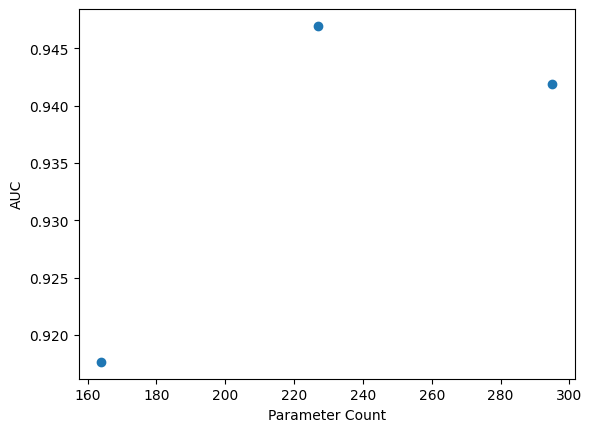

In [49]:
import matplotlib.pyplot as plt

plt.scatter(results_df['param_count'], results_df['auc'])
plt.xlabel('Parameter Count')
plt.ylabel('AUC')
plt.show()

## Fit individual models

In [36]:
# for model in ['mirt']
hub.fit(model='gdina')

-----------------------------------------------------------------
CDM 8.3-14 (2025-07-13 14:03:01) 
GDINA Model 
 Link function: identity 
  ** 2026-01-12 22:33:35.573651 
-----------------------------------------------------------------
...........................................................
Iteration 1     2026-01-12 22:33:35.589475 
Deviance = 11194.04
Maximum parameter change: 0.292549 
...........................................................
Iteration 2     2026-01-12 22:33:35.597647 
Deviance = 9261.206 | Deviance change = 1932.834
Maximum parameter change: 0.246084 
...........................................................
Iteration 3     2026-01-12 22:33:35.606816 
Deviance = 8874.602 | Deviance change = 386.6044
Maximum parameter change: 0.292192 
...........................................................
Iteration 4     2026-01-12 22:33:35.624063 
Deviance = 8707.35 | Deviance change = 167.2521
Maximum parameter change: 0.128591 
....................................

In [37]:
hub.get_info()

{'model': 'GDINA',
 'auc': 0.9469650469544793,
 'train_time': 12.129999999999995,
 'avg_runtime': 0.014906716417910465,
 'param_count': 227.0}

In [31]:
hub.fit('mirt')

F1 = 7,15,19
F2 = 4,5,7,9,10,11,13,14,16,17,18,19,20
F3 = 4,19,20
F4 = 1,2,3,5,13
F5 = 4,10,11,13,17,18,19,20
F6 = 1,18
F7 = 1,2,3,4,5,6,7,8,10,11,12,13,14,15,16,17,18,19,20
F8 = 5,10,12
Iteration: 25, Log-Lik: -4368.389, Max-Change: 0.04364


In [32]:
hub.get_info()

R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: EM cycles terminated after 25 iterations. 
  
R callback write-console: 2: High-dimensional models factor scores should use quasi-Monte Carlo integration. Pass QMC=TRUE 
  


{'model': 'MIRT',
 'auc': 0.9492869751190783,
 'train_time': 18.715000000000032,
 'avg_runtime': 0.014906716417910465,
 'param_count': 164.0}

In [3]:
hub.fit('DINA', X_df, Q_df)

: 

In [22]:
hub.get_info()

(359, 20)
(177, 20)
(359, 20)


ValueError: Found input variables with inconsistent numbers of samples: [177, 359]

In [21]:
hub.fit('acdm')

-----------------------------------------------------------------
CDM 8.3-14 (2025-07-13 14:03:01) 
GDINA Model 
 Link function: identity 
  ** 2026-01-11 21:04:15.954554 
-----------------------------------------------------------------
...........................................................
Iteration 1     2026-01-11 21:04:15.971298 
Deviance = 11194.04
Maximum parameter change: 0.292549 
...........................................................
Iteration 2     2026-01-11 21:04:15.979813 
Deviance = 9261.206 | Deviance change = 1932.834
Maximum parameter change: 0.246084 
...........................................................
Iteration 3     2026-01-11 21:04:15.99001 
Deviance = 8874.602 | Deviance change = 386.6044
Maximum parameter change: 0.292192 
...........................................................
Iteration 4     2026-01-11 21:04:16.007817 
Deviance = 8707.35 | Deviance change = 167.2521
Maximum parameter change: 0.128591 
.....................................

In [16]:
hub.get_info()

{'model': 'DINA',
 'auc': 0.9419339173810218,
 'train_time': 0.27899999999999636,
 'param_count': 295.0}

In [19]:
hub.fit('mola')

NotImplementedError: Conversion 'py2rpy' not defined for objects of type '<class 'NoneType'>'

In [30]:
hub.get_info()

{'model': 'MoLA',
 'auc': 0.917641432537079,
 'train_time': 0.027513742446899414,
 'avg_runtime': 1.1453877634076929e-06,
 'param_count': 164.0}

In [5]:
import time
st = time.time()
et = time.time()

et - st

1.0013580322265625e-05

# Fit MIRT Model

In [ ]:
# Instantiate MIRT model
ro.r("""
library(mirt)

model <- mirt.model("
F1 = 1-7
F2 = 8-14
F3 = 15-20
COV = F1*F2*F3
")
""")

# Fit MIRT model
ro.r("""
fit <- mirt(
  X,
  model,
  itemtype = "2PL",
  method = "EM",
  technical = list(NCYCLES = 500)
)
""")

# Predict probability of correct responses
ro.r('theta_eap <- fscores(fit, method = "EAP")')

# predicted probabilities for all items
ro.r('pred_prob <- probtrace(fit, Theta = theta_eap)')

with localconverter(ro.default_converter + pandas2ri.converter):
    pred_prob = ro.conversion.rpy2py(ro.r('probtrace(fit, Theta = theta_eap)'))

pred_prob_1 = pred_prob[:, 1::2]  # shape (N, J)

# One prediction for each item response in the dataset
assert pred_prob_1.shape == X_df.shape

print('AUC:', roc_auc_score(X_df, pred_prob_1))

Iteration: 12, Log-Lik: -4742.495, Max-Change: 0.0001064


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: Latent trait covariance matrix became non-positive definite. Model may be unstable 
  
R callback write-console: 2: Latent trait covariance matrix became non-positive definite. Model may be unstable 
  
R callback write-console: 3: Log-likelihood was decreasing near the ML solution. EM method may be unstable 
  


AUC: 0.9223918966947059


# Fit GDINA

In [ ]:
ro.r(''' 
# Fit the G-DINA model
est_cdm <- CDM::gdina(X, Q)
     ''')

-----------------------------------------------------------------
CDM 8.3-14 (2025-07-13 14:03:01) 
GDINA Model 
 Link function: identity 
  ** 2026-01-09 12:34:49.599222 
-----------------------------------------------------------------
...........................................................
Iteration 1     2026-01-09 12:34:49.620546 
Deviance = 11194.04
Maximum parameter change: 0.292549 
...........................................................
Iteration 2     2026-01-09 12:34:49.62803 
Deviance = 9261.206 | Deviance change = 1932.834
Maximum parameter change: 0.246084 
...........................................................
Iteration 3     2026-01-09 12:34:49.636166 
Deviance = 8874.602 | Deviance change = 386.6044
Maximum parameter change: 0.292192 
...........................................................
Iteration 4     2026-01-09 12:34:49.65566 
Deviance = 8707.35 | Deviance change = 167.2521
Maximum parameter change: 0.128591 
......................................

In [ ]:
ro.r('''
# Get person-specific latent class probabilities
post <- CDM::IRT.posterior(est_cdm) # shape (536, 256)

# Initialize output matrix
final_probs <- matrix(0, nrow = 536, ncol = 20)
     
item_probs <- pred_obj$expected

# Marginalize over axis 2 (the 256 latent classes)
for (j in 1:20) {
  # Row-wise dot product for each item
  final_probs[, j] <- rowSums(post * item_probs[,,j])
}
''')

with localconverter(ro.default_converter + pandas2ri.converter):
    pred_prob_gdina = ro.conversion.rpy2py(ro.r('final_probs'))

print('GDINA AUC Score:', roc_auc_score(X_df, pred_prob_gdina))

GDINA AUC Score: 0.9469650469544793


## Fit MoLA

Best MoLA AUC Score: 0.9181176704073881
Optimal No. of Components: 20


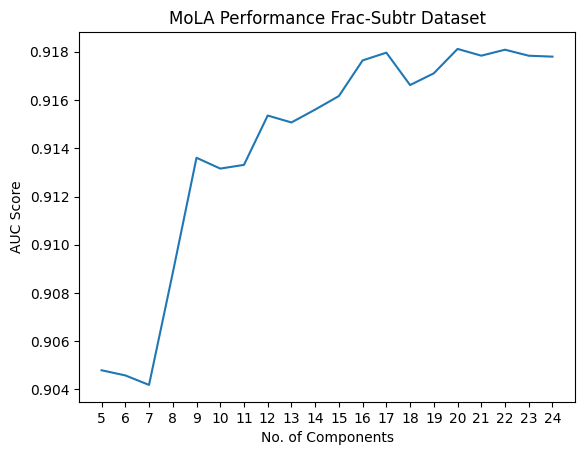

In [ ]:
from aplus.cognitive_model import MoLA

X = X_df.to_numpy()
Q_matrix = Q_matrix_df.to_numpy()

auc_scores = []
cs = np.arange(5, 25, 1)
for n_components in cs:
    # Configure model parameters
    model_params = {
        'Q_matrix': Q_matrix,
        'n_components': n_components,
        'mu_smooth': [2, 2],
        'theta_smooth': [2, 2],
        'pi_smooth': 2,
        'tol': 1e-6,
        'n_iter': 100,
    }

    # Instantiate the model
    model = MoLA(**model_params)

    # Fit the model to the data
    model.fit(X)
    pred_probas = model.pred_item_probas(X)
    auc_scores.append(roc_auc_score(X, pred_probas))

print('Best MoLA AUC Score:', max(auc_scores))
print('Optimal No. of Components:', (cs[np.argmax(auc_scores)]))

plt.plot(auc_scores)
plt.title('MoLA Performance Frac-Subtr Dataset')
plt.ylabel('AUC Score')
plt.xlabel('No. of Components')
plt.xticks(np.arange(len(cs)), labels=cs)

plt.show()